### **Importing Data and Libraries**

In [144]:
# Importing libraries
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pyarrow.parquet import ParquetFile

# Time series and ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [118]:
# Load the dataset
df = pd.read_parquet('final_compressed.parquet')
df.head(1)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,year,month,day
0,2019-10-01 00:00:00+00:00,view,44600062,-251657396,,shiseido,35.790001,541312140,2019,10,1


In [119]:
# Checking the shape of the dataset 
df.shape

(109950743, 11)

In [120]:
# Getting information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109950743 entries, 0 to 109950742
Data columns (total 11 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[ns, UTC]
 1   event_type     category           
 2   product_id     int32              
 3   category_id    int32              
 4   category_code  category           
 5   brand          category           
 6   price          float32            
 7   user_id        int32              
 8   year           int32              
 9   month          int32              
 10  day            int32              
dtypes: category(3), datetime64[ns, UTC](1), float32(1), int32(6)
memory usage: 4.2 GB


In [121]:
# Checking the null values in the dataset
df.isnull().sum()

event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
year             0
month            0
day              0
dtype: int64

In [122]:
# Drop unnescessary columns 
df = df.drop(columns=['year','month','day'])

In [123]:
# Checking first five rows
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id
0,2019-10-01 00:00:00+00:00,view,44600062,-251657396,,shiseido,35.790001,541312140
1,2019-10-01 00:00:00+00:00,view,3900821,-780140327,appliances.environment.water_heater,aqua,33.200001,554748717
2,2019-10-01 00:00:01+00:00,view,17200506,-1904213353,furniture.living_room.sofa,,543.099976,519107250
3,2019-10-01 00:00:01+00:00,view,1307067,1518338663,computers.notebook,lenovo,251.740005,550050854
4,2019-10-01 00:00:04+00:00,view,1004237,-1769995873,electronics.smartphone,apple,1081.979980,535871217


In [124]:
# Taking sample of large data 
df_sample = df.sample(n=2000000, random_state=42)

In [125]:
# Checking shape of the dataset 
df_sample.shape

(2000000, 8)

In [126]:
# Convert Time Column
df_sample['event_time'] = pd.to_datetime(df_sample['event_time'])

In [127]:
# Create Date Column
df_sample['date'] = df_sample['event_time'].dt.date

In [128]:
# Create Customer Level Dataset
customer_df = df_sample.groupby('user_id').agg({
    'event_type':'count',
    'product_id':'nunique',
    'price':'sum',
    'event_time':['min','max']
}).reset_index()

In [129]:
# Rename columns
customer_df.columns = [
    'user_id',
    'total_events',
    'unique_products',
    'total_spend',
    'first_activity',
    'last_activity'
]

In [130]:
# Checking first five rows 
customer_df.head()

,user_id,total_events,unique_products,total_spend,first_activity,last_activity
0,94566147,2,2,358.739990,2019-11-11 07:34:13+00:00,2019-11-14 08:38:59+00:00
1,107837897,1,1,51.220001,2019-11-27 13:59:19+00:00,2019-11-27 13:59:19+00:00
2,116566414,2,1,0.000000,2019-11-24 15:14:39+00:00,2019-11-24 15:23:04+00:00
3,120701478,1,1,487.119995,2019-11-26 04:54:56+00:00,2019-11-26 04:54:56+00:00
4,121339215,2,2,262.529999,2019-11-25 06:00:47+00:00,2019-11-25 06:02:25+00:00


In [131]:
# Create Customer Lifetime
customer_df['lifetime_days'] = (
    customer_df['last_activity'] -
    customer_df['first_activity']
).dt.days

In [132]:
# Create Recency Feature
latest_date = df_sample['event_time'].max()

customer_df['recency_days'] = (
    latest_date -
    customer_df['last_activity']
).dt.days

In [133]:
# Calculate Purchases
purchase_counts = df_sample[df_sample['event_type']=='purchase'] \
                    .groupby('user_id') \
                    .size()

customer_df['total_purchases'] = customer_df['user_id'].map(purchase_counts).fillna(0)

In [134]:
# Average Order Value
customer_df['avg_order_value'] = (
    customer_df['total_spend'] /
    customer_df['total_purchases'].replace(0,1)
)

In [135]:
# Engagement Rate
customer_df['engagement_rate'] = (
    customer_df['total_events'] /
    (customer_df['lifetime_days'] + 1)
)

In [136]:
# Define Churn
customer_df['churn'] = customer_df['recency_days'].apply(
    lambda x: 1 if x > 30 else 0
)

In [137]:
# Checking churn 
customer_df['churn'].value_counts()

churn
0    736197
1    358751
Name: count, dtype: int64

In [140]:
# Preparing ML Dataset 
features = [
'total_events',
'unique_products'
]
X = customer_df[features]
y = customer_df['churn']

In [141]:
# Model training
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [146]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[147062      0]
 [ 71928      0]]
              precision    recall  f1-score   support

           0       0.67      1.00      0.80    147062
           1       0.00      0.00      0.00     71928

    accuracy                           0.67    218990
   macro avg       0.34      0.50      0.40    218990
weighted avg       0.45      0.67      0.54    218990



In [145]:
# Cohort analysis
customer_df['signup_month'] = customer_df['first_activity'].dt.to_period('M')
cohort = customer_df.groupby('signup_month')['user_id'].count()
print(cohort)

signup_month
2019-10    504833
2019-11    590115
Freq: M, Name: user_id, dtype: int64


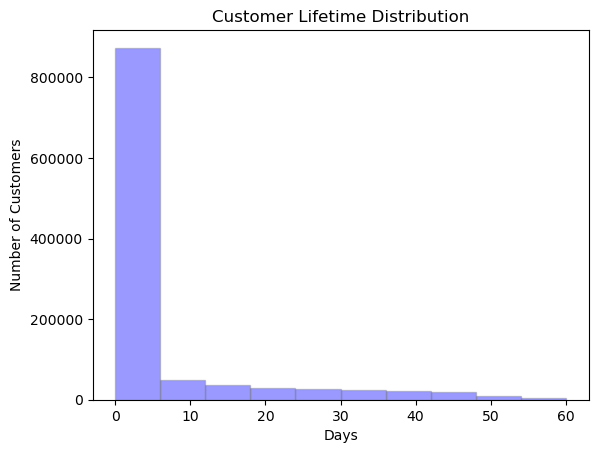

In [150]:
# Customer lifetime analysis 
plt.hist(customer_df['lifetime_days'],edgecolor='grey',color = 'blue',alpha=0.4)
plt.title("Customer Lifetime Distribution")
plt.xlabel("Days")
plt.ylabel("Number of Customers")
plt.show()

<Axes: >

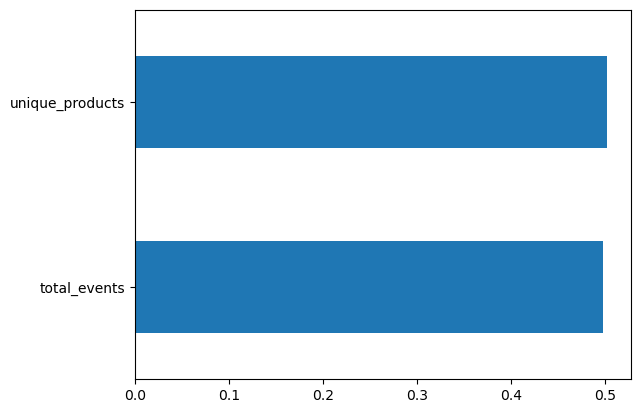

In [151]:
# Chrun Drivers 
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

In [153]:
# Retention Metrics

# Compute churn rate
churn_rate = customer_df['churn'].mean()
print("Churn Rate:", churn_rate)

# Retention rate
retention_rate = 1 - churn_rate
print("Retention Rate:", retention_rate)

Churn Rate: 0.3276420432751144
Retention Rate: 0.6723579567248856


In [154]:
# Create Daily Activity Time Series
daily_activity = df_sample.groupby('date').size()

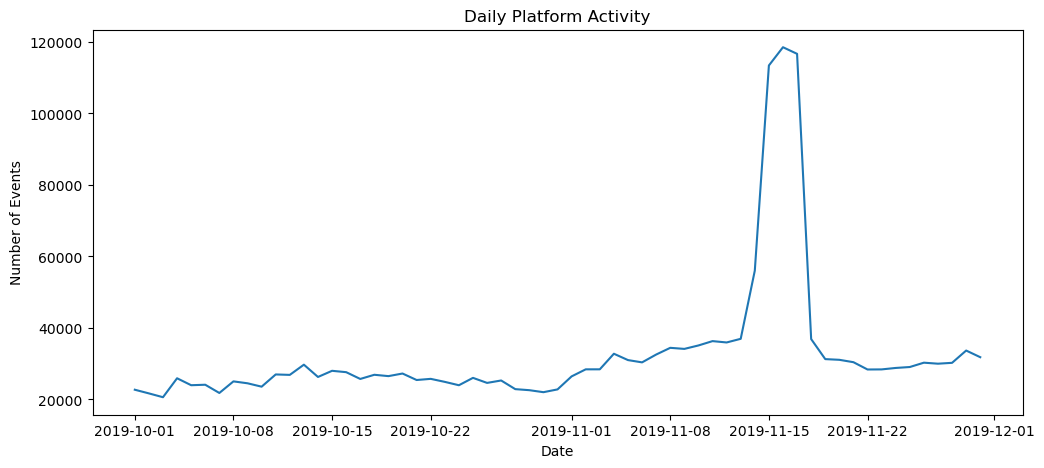

In [155]:
plt.figure(figsize=(12,5))
daily_activity.plot()
plt.title("Daily Platform Activity")
plt.xlabel("Date")
plt.ylabel("Number of Events")
plt.show()

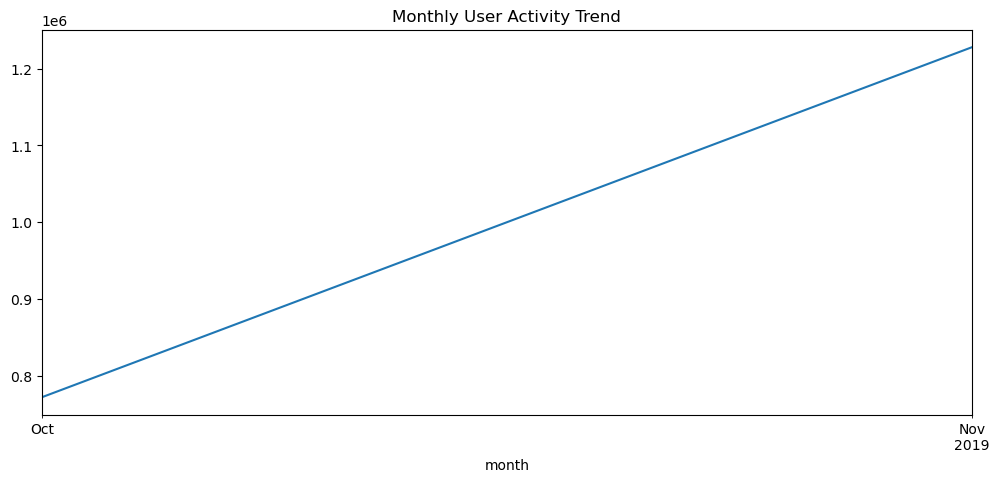

In [156]:
# Monthly Activity Trend
df_sample['month'] = df_sample['event_time'].dt.to_period('M')

monthly_activity = df_sample.groupby('month').size()

monthly_activity.plot(figsize=(12,5))
plt.title("Monthly User Activity Trend")
plt.show()

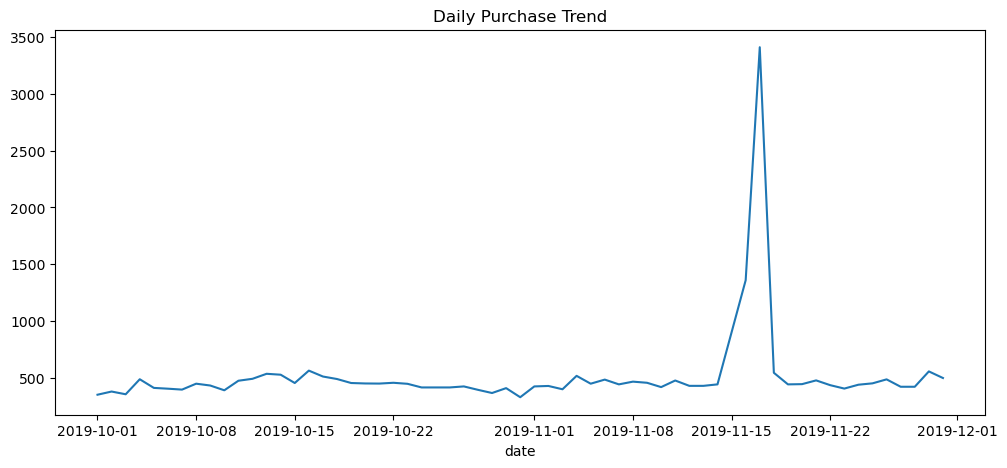

In [157]:
# Purchase Trend Over Time
purchase_df = df_sample[df_sample['event_type'] == 'purchase']

daily_purchases = purchase_df.groupby('date').size()

daily_purchases.plot(figsize=(12,5))
plt.title("Daily Purchase Trend")
plt.show()

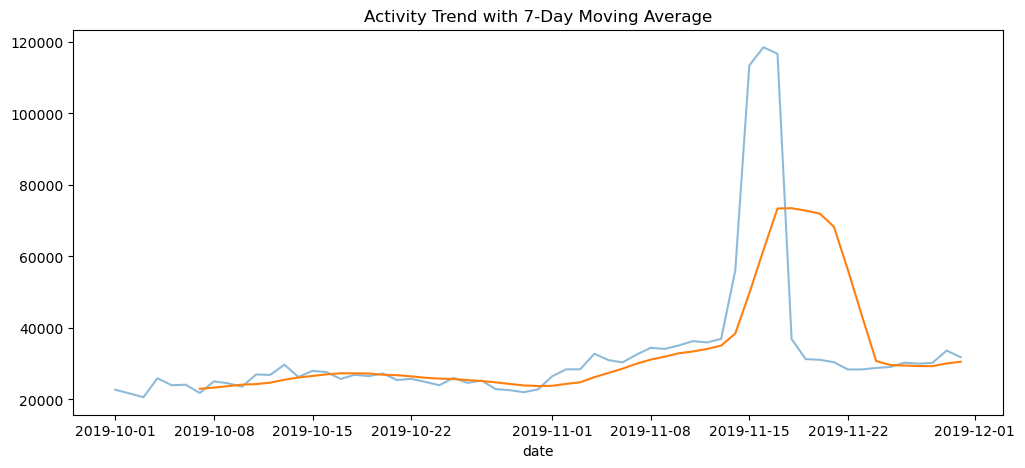

In [158]:
# Moving Average
rolling_activity = daily_activity.rolling(window=7).mean()

plt.figure(figsize=(12,5))
daily_activity.plot(alpha=0.5)
rolling_activity.plot()
plt.title("Activity Trend with 7-Day Moving Average")
plt.show()

In [159]:
# ARIMA Forcasting 
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(daily_activity, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=7)
print(forecast)

2019-12-01    31433.110910
2019-12-02    31389.350521
2019-12-03    31384.322885
2019-12-04    31383.745259
2019-12-05    31383.678896
2019-12-06    31383.671271
2019-12-07    31383.670395
Freq: D, Name: predicted_mean, dtype: float64
